# U-Net Implementation for Leaf Disease Segmentation
### With Layer-by-Layer Feature Map Visualization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

## Generate Synthetic Leaf Image (Demo Purpose)

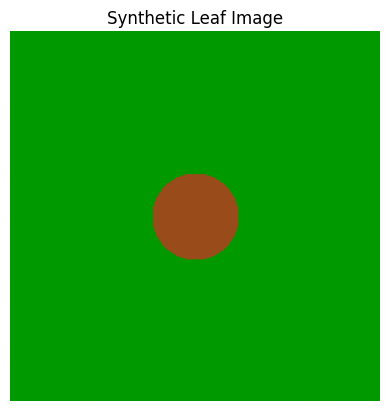

In [ ]:
img = np.zeros((256,256,3))
img[:,:,1] = 0.6

for i in range(256):
    for j in range(256):
        if (i-128)**2 + (j-128)**2 < 30**2:
            img[i,j] = [0.6,0.3,0.1]

plt.figure()
plt.imshow(img)
plt.title('Synthetic Leaf Image')
plt.axis('off')
plt.show()

## Build U-Net Model

In [ ]:
def unet_model():
    inputs = layers.Input((256,256,3))

    c1 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    b = layers.Conv2D(128,(3,3),activation='relu',padding='same')(p2)

    u1 = layers.UpSampling2D((2,2))(b)
    u1 = layers.concatenate([u1,c2])
    c3 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(u1)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.concatenate([u2,c1])
    c4 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,(1,1),activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model = unet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │         33 │ conv2d_6[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,793 (1.06 MB)

 Trainable params: 277,793 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

## Forward Pass (Visualization)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


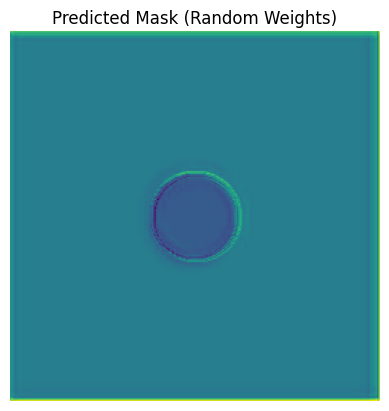

In [ ]:
img_input = np.expand_dims(img,axis=0)
prediction = model.predict(img_input)

plt.figure()
plt.imshow(prediction[0,:,:,0])
plt.title('Predicted Mask (Random Weights)')
plt.axis('off')
plt.show()

## Layer-by-Layer Feature Map Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step


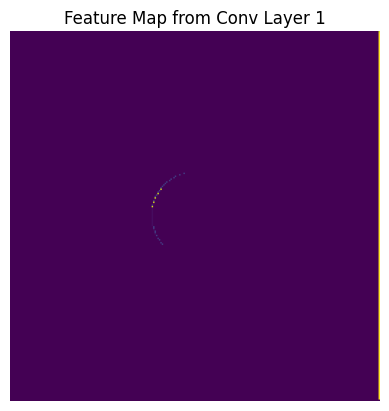

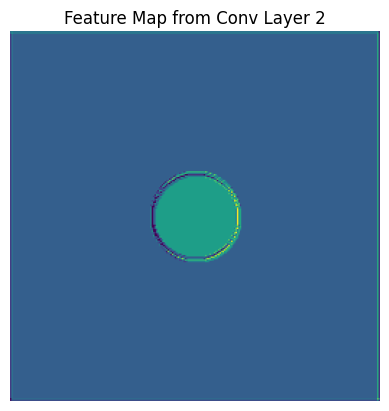

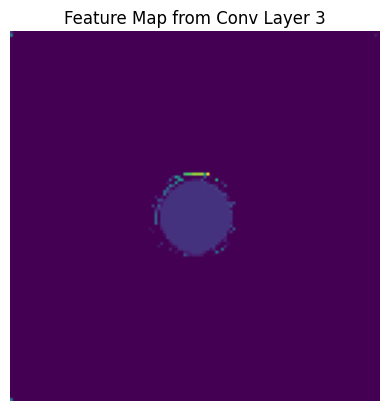

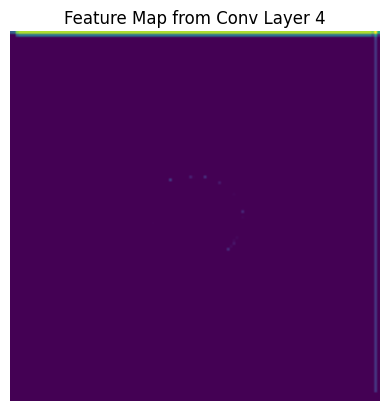

In [ ]:
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
feature_model = models.Model(inputs=model.input, outputs=layer_outputs)

features = feature_model.predict(img_input)

for i in range(min(4,len(features))):
    plt.figure()
    plt.imshow(features[i][0,:,:,0])
    plt.title(f'Feature Map from Conv Layer {i+1}')
    plt.axis('off')
    plt.show()